# 04. CRF

This notebook is dedicated to a single POS-tagging model: **CRF**.

It contains:
- the minimal benchmark-loading utilities
- the implementation of this model only
- shared evaluation helpers
- one training/evaluation run
- inline plots and error analysis for this model


## Model Role

A conditional random field that models the full tag sequence while using hand-crafted contextual features.

Keeping one model per notebook makes the experiments easier to run, inspect, and rerun independently.


In [1]:
from pathlib import Path
import time

from tqdm import tqdm


## Minimal Benchmark Utilities

The notebook reloads the benchmark directly from `data/raw/`, so it does not depend on precomputed artifacts.


In [2]:
import random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
from conllu import parse_incr


# Fixed raw filenames for the shared UD English EWT benchmark.
RAW_FILENAMES = {
    'train': 'en_ewt-ud-train.conllu',
    'dev': 'en_ewt-ud-dev.conllu',
    'test': 'en_ewt-ud-test.conllu',
}


@dataclass
class SentenceRecord:
    sentence_id: str
    tokens: list[str]
    tags: list[str]
    metadata: dict[str, Any]


def set_seed(seed: int = 13) -> None:
    # Keep randomization stable across Python, NumPy, and Torch runs.
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch

        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass


def normalize_neural_token(token: str) -> str:
    # Light normalization is only used by the neural model vocabulary.
    if token.isdigit():
        return '<NUM>'
    if any(char.isdigit() for char in token):
        return '<HASDIGIT>'
    return token.lower()


def load_conllu_sentences(path: str | Path, tag_field: str = 'upostag') -> list[SentenceRecord]:
    path_obj = Path(path)
    sentences: list[SentenceRecord] = []
    with path_obj.open('r', encoding='utf-8') as handle:
        for sentence_index, tokenlist in enumerate(parse_incr(handle)):
            tokens, tags = [], []
            for token in tokenlist:
                token_id = token.get('id')
                if not isinstance(token_id, int):
                    continue
                surface = token.get('form')
                tag = token.get(tag_field)
                if surface is None or tag is None:
                    continue
                tokens.append(str(surface))
                tags.append(str(tag))
            if not tokens:
                continue
            sentences.append(
                SentenceRecord(
                    sentence_id=tokenlist.metadata.get('sent_id', f'{path_obj.stem}-{sentence_index:05d}'),
                    tokens=tokens,
                    tags=tags,
                    metadata=dict(tokenlist.metadata),
                )
            )
    return sentences


def build_vocabulary(
    sentences: list[SentenceRecord],
    lowercase: bool = False,
    normalize: bool = False,
) -> Counter[str]:
    vocab: Counter[str] = Counter()
    for sentence in sentences:
        for token in sentence.tokens:
            key = normalize_neural_token(token) if normalize else token.lower() if lowercase else token
            vocab[key] += 1
    return vocab


def get_label_set(sentences: list[SentenceRecord]) -> list[str]:
    return sorted({tag for sentence in sentences for tag in sentence.tags})


def sentence_oov_rate(tokens: list[str], train_vocabulary: set[str]) -> float:
    if not tokens:
        return 0.0
    return sum(token not in train_vocabulary for token in tokens) / len(tokens)


def split_statistics(
    name: str,
    sentences: list[SentenceRecord],
    train_vocabulary: set[str] | None = None,
) -> dict[str, Any]:
    lengths = [len(sentence.tokens) for sentence in sentences]
    token_total = sum(lengths)
    tag_counter = Counter(tag for sentence in sentences for tag in sentence.tags)
    vocabulary = {token for sentence in sentences for token in sentence.tokens}
    stats: dict[str, Any] = {
        'split': name,
        'num_sentences': len(sentences),
        'num_tokens': token_total,
        'avg_sentence_length': round(float(np.mean(lengths)), 3),
        'median_sentence_length': round(float(np.median(lengths)), 3),
        'max_sentence_length': max(lengths),
        'vocabulary_size': len(vocabulary),
        'num_tags': len(tag_counter),
    }
    if train_vocabulary is not None:
        oov_rates = [sentence_oov_rate(sentence.tokens, train_vocabulary) for sentence in sentences]
        flat_oov = sum(token not in train_vocabulary for sentence in sentences for token in sentence.tokens)
        stats['token_oov_rate'] = round(flat_oov / token_total, 5)
        stats['avg_sentence_oov_rate'] = round(float(np.mean(oov_rates)), 5)
    return stats


def load_benchmark(raw_dir: str | Path = 'data/raw', tag_field: str = 'upostag') -> dict[str, list[SentenceRecord]]:
    raw_dir_path = Path(raw_dir)
    return {
        split: load_conllu_sentences(raw_dir_path / filename, tag_field=tag_field)
        for split, filename in RAW_FILENAMES.items()
    }


## Base Tagger Interface


In [3]:
import pickle
from abc import ABC, abstractmethod
from typing import Iterable


# The benchmark only needs a tiny shared interface: fit, predict, and size.
class BaseSequenceTagger(ABC):
    name: str = 'base'

    @abstractmethod
    def fit(self, train_data: list[SentenceRecord], dev_data: list[SentenceRecord] | None = None) -> None:
        """Train the tagger."""

    @abstractmethod
    def predict(self, dataset: Iterable[SentenceRecord]) -> list[list[str]]:
        """Predict a tag sequence for each sentence."""

    def get_model_size_bytes(self) -> int:
        return len(pickle.dumps(self))


## CRF Implementation


In [4]:
import string
from typing import Iterable

import sklearn_crfsuite



def word_shape(token: str) -> str:
    result = []
    for char in token:
        if char.isupper():
            result.append("X")
        elif char.islower():
            result.append("x")
        elif char.isdigit():
            result.append("d")
        else:
            result.append(char)
    return "".join(result[:8])


def token_features(tokens: list[str], index: int) -> dict[str, str | bool]:
    token = tokens[index]
    lower = token.lower()
    features: dict[str, str | bool] = {
        "bias": True,
        "word": token,
        "lower": lower,
        "shape": word_shape(token),
        "prefix1": lower[:1],
        "prefix2": lower[:2],
        "prefix3": lower[:3],
        "suffix1": lower[-1:],
        "suffix2": lower[-2:],
        "suffix3": lower[-3:],
        "suffix4": lower[-4:],
        "is_upper": token.isupper(),
        "is_title": token.istitle(),
        "is_digit": token.isdigit(),
        "has_digit": any(char.isdigit() for char in token),
        "has_hyphen": "-" in token,
        "is_punct": token in string.punctuation,
    }

    if index == 0:
        features["BOS"] = True
    else:
        prev = tokens[index - 1]
        features["-1:word"] = prev
        features["-1:lower"] = prev.lower()
        features["-1:is_title"] = prev.istitle()
        features["-1:is_upper"] = prev.isupper()

    if index == len(tokens) - 1:
        features["EOS"] = True
    else:
        nxt = tokens[index + 1]
        features["+1:word"] = nxt
        features["+1:lower"] = nxt.lower()
        features["+1:is_title"] = nxt.istitle()
        features["+1:is_upper"] = nxt.isupper()

    if index > 1:
        prev2 = tokens[index - 2]
        features["-2:lower"] = prev2.lower()
    if index < len(tokens) - 2:
        next2 = tokens[index + 2]
        features["+2:lower"] = next2.lower()

    return features


class CRFTagger(BaseSequenceTagger):
    name = "crf"

    def __init__(self, c1: float = 0.1, c2: float = 0.1, max_iterations: int = 100) -> None:
        self.c1 = c1
        self.c2 = c2
        self.max_iterations = max_iterations
        self.model = sklearn_crfsuite.CRF(
            algorithm="lbfgs",
            c1=self.c1,
            c2=self.c2,
            max_iterations=self.max_iterations,
            all_possible_transitions=True,
        )

    def fit(
        self,
        train_data: list[SentenceRecord],
        dev_data: list[SentenceRecord] | None = None,
    ) -> None:
        del dev_data
        X_train = [[token_features(sentence.tokens, i) for i in range(len(sentence.tokens))] for sentence in train_data]
        y_train = [sentence.tags for sentence in train_data]
        self.model.fit(X_train, y_train)

    def predict(self, dataset: Iterable[SentenceRecord]) -> list[list[str]]:
        features = [[token_features(sentence.tokens, i) for i in range(len(sentence.tokens))] for sentence in dataset]
        return self.model.predict(features)


## Shared Evaluation Helpers


In [5]:
import time
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support


# Buckets are intentionally coarse so the plots stay readable.
LENGTH_BUCKETS = [('1-10', 1, 10), ('11-20', 11, 20), ('21-30', 21, 30), ('31+', 31, None)]
OOV_BUCKETS = [('0%', 0.0, 0.0), ('low', 0.0, 0.1), ('medium', 0.1, 0.3), ('high', 0.3, None)]


def flatten(nested: list[list[str]]) -> list[str]:
    return [item for sublist in nested for item in sublist]


def bucket_by_length(length: int) -> str:
    for label, start, end in LENGTH_BUCKETS:
        if (end is None and length >= start) or (end is not None and start <= length <= end):
            return label
    return 'unknown'


def bucket_by_oov_rate(rate: float) -> str:
    for label, start, end in OOV_BUCKETS:
        if label == '0%' and rate == 0.0:
            return label
        if (end is None and rate > start) or (end is not None and start < rate <= end):
            return label
    return '0%'


def top_confusions(cm: np.ndarray, labels: list[str], limit: int = 15) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for i, gold in enumerate(labels):
        for j, predicted in enumerate(labels):
            if i != j and cm[i, j] > 0:
                rows.append({'gold_tag': gold, 'predicted_tag': predicted, 'count': int(cm[i, j])})
    rows.sort(key=lambda row: row['count'], reverse=True)
    return rows[:limit]


def grouped_sentence_metrics(
    dataset: list[SentenceRecord],
    predictions: list[list[str]],
    train_vocabulary: set[str],
) -> tuple[pd.DataFrame, pd.DataFrame, list[dict[str, Any]]]:
    # Aggregate errors both by sentence length and by OOV pressure.
    length_rows, oov_rows, error_examples = [], [], []
    for sentence, predicted_tags in zip(dataset, predictions):
        token_total = len(sentence.tags)
        correct = sum(gold == pred for gold, pred in zip(sentence.tags, predicted_tags))
        oov_rate = sentence_oov_rate(sentence.tokens, train_vocabulary)
        length_bucket = bucket_by_length(len(sentence.tokens))
        oov_bucket = bucket_by_oov_rate(oov_rate)
        length_rows.append({'bucket': length_bucket, 'correct': correct, 'total': token_total})
        oov_rows.append({'bucket': oov_bucket, 'correct': correct, 'total': token_total})
        if correct < token_total:
            mismatches = [
                {'token': token, 'gold': gold, 'pred': pred}
                for token, gold, pred in zip(sentence.tokens, sentence.tags, predicted_tags)
                if gold != pred
            ]
            error_examples.append({
                'sentence_id': sentence.sentence_id,
                'tokens': sentence.tokens,
                'gold_tags': sentence.tags,
                'predicted_tags': predicted_tags,
                'oov_rate': round(oov_rate, 4),
                'length_bucket': length_bucket,
                'oov_bucket': oov_bucket,
                'mismatches': mismatches,
            })
    length_df = pd.DataFrame(length_rows).groupby('bucket', as_index=False).sum()
    oov_df = pd.DataFrame(oov_rows).groupby('bucket', as_index=False).sum()
    for frame in (length_df, oov_df):
        frame['accuracy'] = frame['correct'] / frame['total']
        frame['error_rate'] = 1.0 - frame['accuracy']
    error_examples.sort(key=lambda row: len(row['mismatches']), reverse=True)
    return length_df, oov_df, error_examples[:30]


## Experiment Configuration


In [6]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'

SEED = 13
TAG_FIELD = 'upostag'
RUN_TEST = True
MODEL_NAME = 'crf'
MODEL_TITLE = 'CRF'
MODEL_DESCRIPTION = "A conditional random field that models the full tag sequence while using hand-crafted contextual features."


def build_benchmark_in_memory(raw_dir: str | Path = 'data/raw', tag_field: str = 'upostag') -> dict[str, Any]:
    dataset = load_benchmark(raw_dir=raw_dir, tag_field=tag_field)
    train_vocab = set(build_vocabulary(dataset['train']).keys())
    stats = {
        split: split_statistics(split, sentences, train_vocabulary=train_vocab if split != 'train' else None)
        for split, sentences in dataset.items()
    }
    return {'dataset': dataset, 'stats': stats, 'train_vocabulary': train_vocab, 'labels': get_label_set(dataset['train'])}


def evaluate_predictions_inline(
    model_name: str,
    dataset: list[SentenceRecord],
    predictions: list[list[str]],
    labels: list[str],
    train_vocabulary: set[str],
    split_name: str,
    train_time_s: float | None = None,
    inference_time_s: float | None = None,
    model_size_bytes: int | None = None,
) -> dict[str, Any]:
    gold = flatten([sentence.tags for sentence in dataset])
    pred = flatten(predictions)
    accuracy = sum(g == p for g, p in zip(gold, pred)) / max(len(gold), 1)
    precision, recall, f1, support = precision_recall_fscore_support(gold, pred, labels=labels, zero_division=0)
    cm = confusion_matrix(gold, pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    length_df, oov_df, error_examples = grouped_sentence_metrics(dataset, predictions, train_vocabulary)
    per_tag_df = pd.DataFrame({'tag': labels, 'precision': precision, 'recall': recall, 'f1': f1, 'support': support}).sort_values(by='f1', ascending=False)
    metrics = {
        'model': model_name,
        'split': split_name,
        'token_accuracy': round(float(accuracy), 6),
        'macro_f1': round(float(np.mean(f1)), 6),
        'train_time_s': None if train_time_s is None else round(float(train_time_s), 4),
        'inference_time_s': None if inference_time_s is None else round(float(inference_time_s), 4),
        'tokens_per_second': None if not inference_time_s else round(len(gold) / inference_time_s, 2),
        'model_size_mb': None if model_size_bytes is None else round(model_size_bytes / (1024 * 1024), 4),
        'num_sentences': len(dataset),
        'num_tokens': len(gold),
    }
    return {
        'metrics': metrics,
        'per_tag_df': per_tag_df,
        'confusion_matrix_df': cm_df,
        'top_confusions_df': pd.DataFrame(top_confusions(cm, labels)),
        'length_df': length_df,
        'oov_df': oov_df,
        'error_examples_df': pd.DataFrame(error_examples),
    }


def evaluate_model_inline(
    tagger: BaseSequenceTagger,
    dataset: list[SentenceRecord],
    labels: list[str],
    train_vocabulary: set[str],
    split_name: str,
    train_time_s: float | None = None,
) -> dict[str, Any]:
    start = time.perf_counter()
    predictions = tagger.predict(dataset)
    inference_time_s = time.perf_counter() - start
    return evaluate_predictions_inline(
        model_name=tagger.name,
        dataset=dataset,
        predictions=predictions,
        labels=labels,
        train_vocabulary=train_vocabulary,
        split_name=split_name,
        train_time_s=train_time_s,
        inference_time_s=inference_time_s,
        model_size_bytes=tagger.get_model_size_bytes(),
    )


def train_and_evaluate_single_model(
    tagger: BaseSequenceTagger,
    dataset: dict[str, list[SentenceRecord]],
    labels: list[str],
    train_vocabulary: set[str],
    run_test: bool,
) -> dict[str, Any]:
    print(f'Training {MODEL_TITLE} ...')
    start = time.perf_counter()
    tagger.fit(dataset['train'], dataset['dev'])
    train_time_s = time.perf_counter() - start
    run = {
        'name': tagger.name,
        'display_name': MODEL_TITLE,
        'train_time_s': train_time_s,
        'dev': evaluate_model_inline(tagger, dataset['dev'], labels, train_vocabulary, 'dev', train_time_s),
        'test': None,
    }
    run['dev']['metrics'].update(model_metadata)
    if run_test:
        run['test'] = evaluate_model_inline(tagger, dataset['test'], labels, train_vocabulary, 'test', train_time_s)
        run['test']['metrics'].update(model_metadata)
    return run


def plot_single_model_buckets(run: dict[str, Any], split_name: str) -> None:
    artifact = run[split_name]
    if artifact is None:
        print('No artifact available for split', split_name)
        return
    for title, frame in [
        (f"{split_name.title()} Error Rate By Sentence Length", artifact['length_df']),
        (f"{split_name.title()} Error Rate By OOV Bucket", artifact['oov_df']),
    ]:
        plt.figure(figsize=(8, 4))
        sns.barplot(data=frame, x='bucket', y='error_rate', hue='bucket', legend=False)
        plt.title(title)
        plt.xlabel('Bucket')
        plt.ylabel('Error rate')
        plt.tight_layout()
        plt.show()


def render_model_diagnostics(run: dict[str, Any], split_name: str) -> None:
    artifact = run[split_name]
    if artifact is None:
        print('No artifact available for', MODEL_TITLE, split_name)
        return
    print(MODEL_TITLE, '| split =', split_name)
    display(pd.DataFrame([artifact['metrics']]))
    print('Top tag confusions')
    display(artifact['top_confusions_df'].head(10))
    print('Best and worst per-tag F1')
    display(artifact['per_tag_df'].head(8))
    display(artifact['per_tag_df'].tail(8))
    plt.figure(figsize=(8, 6))
    sns.heatmap(artifact['confusion_matrix_df'], cmap='YlGnBu', square=True)
    plt.title(f"Confusion Matrix: {MODEL_TITLE} ({split_name})")
    plt.tight_layout()
    plt.show()
    if not artifact['error_examples_df'].empty:
        print('Representative error examples')
        display(artifact['error_examples_df'][['sentence_id', 'oov_rate', 'length_bucket', 'oov_bucket', 'mismatches']].head(3))


print('Project root:', PROJECT_ROOT)
print('Tag field:', TAG_FIELD)
print('Current model notebook:', MODEL_TITLE)


Project root: /Users/nikronbecon/Desktop/Case_study
Tag field: upostag
Current model notebook: CRF


## Reload The Benchmark


In [7]:
set_seed(SEED)
benchmark = build_benchmark_in_memory(raw_dir=RAW_DIR, tag_field=TAG_FIELD)
dataset = benchmark['dataset']
labels = benchmark['labels']
train_vocabulary = benchmark['train_vocabulary']

pd.DataFrame(benchmark['stats'].values())


,split,num_sentences,num_tokens,avg_sentence_length,median_sentence_length,max_sentence_length,vocabulary_size,num_tags,token_oov_rate,avg_sentence_oov_rate
0,train,12544,204577,16.309,14.0,159,19674,17,NaN,NaN
1,dev,2001,25147,12.567,10.0,75,5494,17,0.08303,0.12843
2,test,2077,25094,12.082,9.0,81,5629,17,0.09134,0.13837


## Instantiate CRF


In [8]:
model = CRFTagger(c1=0.1, c2=0.1, max_iterations=75)
model_metadata = {'interpretability': 'high', 'implementation_complexity': 'medium'}


## Train And Evaluate CRF

This is the main execution cell for the model.


In [9]:
model_run = train_and_evaluate_single_model(model, dataset, labels, train_vocabulary, RUN_TEST)
display(pd.DataFrame([
    model_run['dev']['metrics'],
    *([model_run['test']['metrics']] if model_run['test'] is not None else []),
]))
comparison_split = 'dev' if model_run['test'] is None else 'test'


Training CRF ...


,model,split,token_accuracy,macro_f1,train_time_s,inference_time_s,tokens_per_second,model_size_mb,num_sentences,num_tokens,interpretability,implementation_complexity
0,crf,dev,0.945838,0.896580,22.9582,0.1419,177238.47,4.6725,2001,25147,high,medium
1,crf,test,0.946880,0.899161,22.9582,0.1398,179476.44,4.6725,2077,25094,high,medium


## Intermediate Conclusion: Quality And Role

CRF is the strongest classical model in the project. Its final quality is close to the neural model, while training and inference remain dramatically cheaper.


## Error Plots

The two charts below appear directly as notebook outputs.


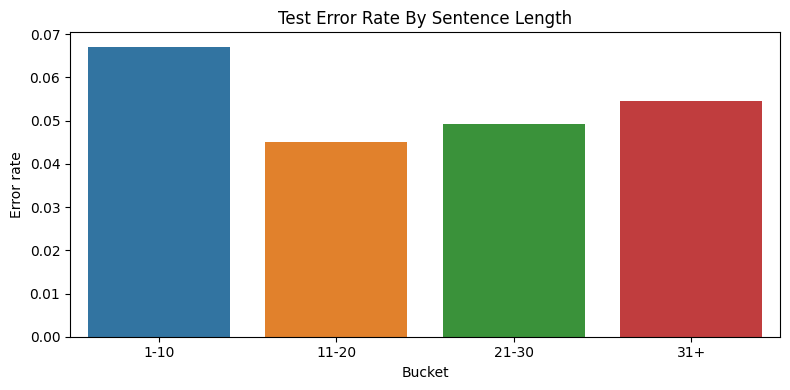

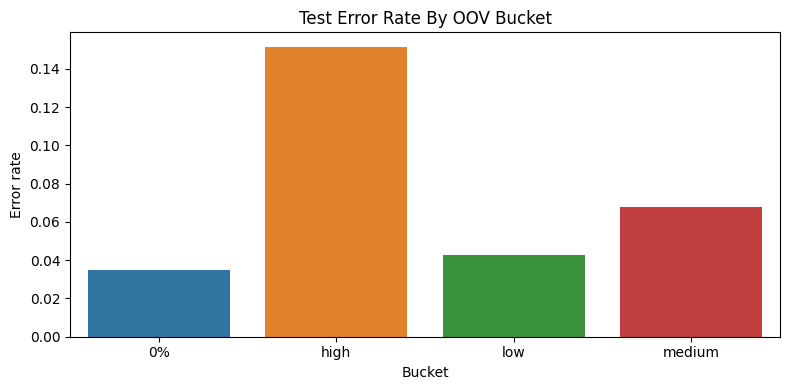

In [10]:
plot_single_model_buckets(model_run, comparison_split)


## Intermediate Conclusion: Robustness Pattern

The bucket plots show why CRF is the strongest practical trade-off: it stays robust on harder examples while avoiding the computational cost of the BiLSTM.


## Detailed Diagnostics


CRF | split = test


,model,split,token_accuracy,macro_f1,train_time_s,inference_time_s,tokens_per_second,model_size_mb,num_sentences,num_tokens,interpretability,implementation_complexity
0,crf,test,0.94688,0.899161,22.9582,0.1398,179476.44,4.6725,2077,25094,high,medium


Top tag confusions


,gold_tag,predicted_tag,count
0,PROPN,NOUN,210
1,NOUN,PROPN,174
2,VERB,NOUN,70
3,ADJ,NOUN,64
4,NOUN,ADJ,49
5,NOUN,VERB,47
6,SCONJ,ADP,47
7,ADJ,VERB,46
8,ADV,ADJ,40
9,ADJ,ADV,38


Best and worst per-tag F1


,tag,precision,recall,f1,support
12,PUNCT,0.995472,0.994186,0.994829,3096
4,CCONJ,0.994550,0.991848,0.993197,736
5,DET,0.991548,0.989457,0.990501,1897
3,AUX,0.985142,0.988334,0.986736,1543
10,PRON,0.985233,0.986599,0.985915,2164
9,PART,0.961019,0.987673,0.974164,649
1,ADP,0.944123,0.967901,0.955864,2025
15,VERB,0.950076,0.957006,0.953528,2605


,tag,precision,recall,f1,support
2,ADV,0.924191,0.910999,0.917548,1191
7,NOUN,0.906079,0.921902,0.913922,4123
0,ADJ,0.919448,0.893736,0.906410,1788
6,INTJ,0.970588,0.818182,0.887892,121
11,PROPN,0.880847,0.862169,0.871408,2075
14,SYM,0.848739,0.893805,0.870690,113
13,SCONJ,0.891429,0.812500,0.850136,384
16,X,0.533333,0.190476,0.280702,42


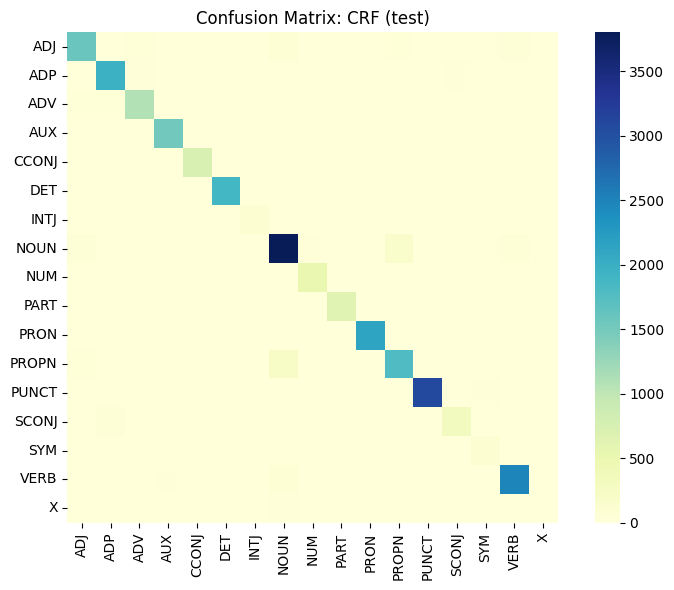

Representative error examples


,sentence_id,oov_rate,length_bucket,oov_bucket,mismatches
0,newsgroup-groups.google.com_HumorUniversity_00...,0.3421,31+,high,"[{'token': 'Twinkle', 'gold': 'VERB', 'pred': ..."
1,answers-20111106103415AAqdokn_ans-0002,0.1111,21-30,medium,"[{'token': 'metro', 'gold': 'ADJ', 'pred': 'PR..."
2,weblog-blogspot.com_aggressivevoicedaily_20060...,0.1316,31+,medium,"[{'token': 'Parts', 'gold': 'NOUN', 'pred': 'P..."


In [11]:
render_model_diagnostics(model_run, comparison_split)


## Intermediate Conclusion: Error Profile

CRF improves over the perceptron not by changing the nature of the task, but by reducing the frequency of the same recurring mistakes. This supports the interpretation that structured prediction helps sequence consistency without giving up interpretability.


## Notebook Scope

This notebook contains the full run for this single model: data reload, training, evaluation, plots, and qualitative error inspection.
